**Importing the required libraries**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot  as plt

**Loading the Dataset**

In [2]:
df=pd.read_csv('/kaggle/input/largest-companies-by-market-cap/companiesmarketcap.csv')
print(df.head())

   Rank      Company Names Company Code Marketcap Stock Price Origin Flag  \
0   1.0          Microsoft         MSFT  $3.033 T     $407.21          🇺🇸   
1   2.0              Apple         AAPL  $2.951 T     $190.92          🇺🇸   
2   3.0       Saudi Aramco      2222.SR  $2.026 T       $8.34          🇸🇦   
3   4.0  Alphabet (Google)         GOOG  $1.909 T     $153.46          🇺🇸   
4   5.0             Amazon         AMZN  $1.653 T     $160.05          🇺🇸   

     Country  
0        USA  
1        USA  
2  S. Arabia  
3        USA  
4        USA  


**Changing Marketcap and Stock Price into Numeric**

In [3]:
df['Marketcap'] = pd.to_numeric(df['Marketcap'].replace('[\$,TKMB]', '', regex=True)) * df['Marketcap'].str.extract('([TBMK])', expand=False).replace({'T': 1e12, 'B': 1e9, 'M': 1e6, 'K': 1e3})
df['Stock Price'] = pd.to_numeric(df['Stock Price'].replace('[\$,]', '', regex=True))
df.head()

/tmp/ipykernel_18/1094280657.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Marketcap'] = pd.to_numeric(df['Marketcap'].replace('[\$,TKMB]', '', regex=True)) * df['Marketcap'].str.extract('([TBMK])', expand=False).replace({'T': 1e12, 'B': 1e9, 'M': 1e6, 'K': 1e3})


,Rank,Company Names,Company Code,Marketcap,Stock Price,Origin Flag,Country
0,1.0,Microsoft,MSFT,3.033000e+12,407.21,🇺🇸,USA
1,2.0,Apple,AAPL,2.951000e+12,190.92,🇺🇸,USA
2,3.0,Saudi Aramco,2222.SR,2.026000e+12,8.34,🇸🇦,S. Arabia
3,4.0,Alphabet (Google),GOOG,1.909000e+12,153.46,🇺🇸,USA
4,5.0,Amazon,AMZN,1.653000e+12,160.05,🇺🇸,USA


**Top 50 Companies**

In [4]:
top_cmp=df.head(15)
top_cmp


,Rank,Company Names,Company Code,Marketcap,Stock Price,Origin Flag,Country
0,1.0,Microsoft,MSFT,3.033000e+12,407.21,🇺🇸,USA
1,2.0,Apple,AAPL,2.951000e+12,190.92,🇺🇸,USA
2,3.0,Saudi Aramco,2222.SR,2.026000e+12,8.34,🇸🇦,S. Arabia
3,4.0,Alphabet (Google),GOOG,1.909000e+12,153.46,🇺🇸,USA
4,5.0,Amazon,AMZN,1.653000e+12,160.05,🇺🇸,USA
5,6.0,NVIDIA,NVDA,1.522000e+12,616.49,🇺🇸,USA
6,7.0,Meta Platforms (Facebook),META,1.027000e+12,399.96,🇺🇸,USA
7,8.0,Berkshire Hathaway,BRK-B,8.262200e+11,380.36,🇺🇸,USA
8,9.0,Eli Lilly,LLY,6.114300e+11,644.09,🇺🇸,USA
9,10.0,TSMC,TSM,6.028600e+11,116.24,🇹🇼,Taiwan


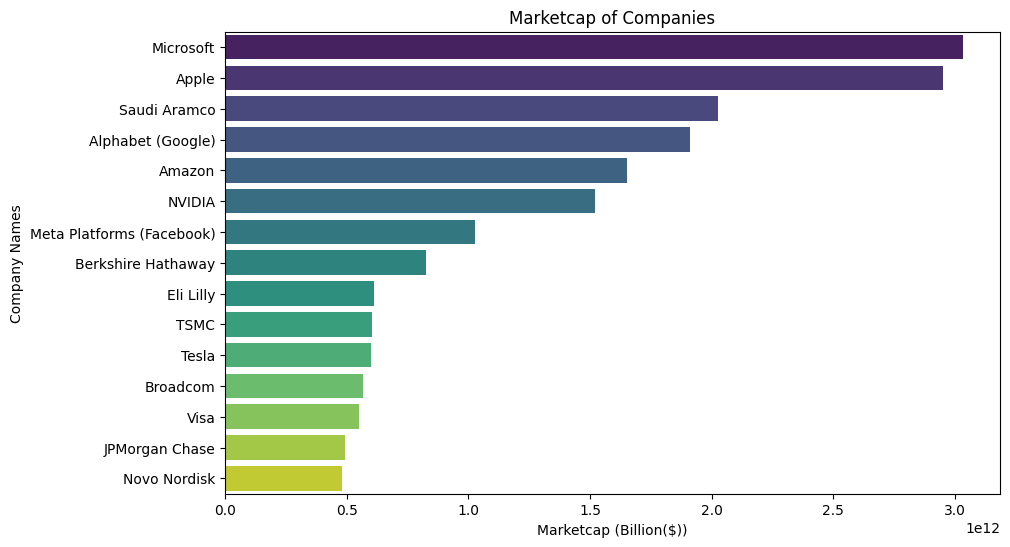

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Marketcap', y='Company Names', data=top_cmp, palette='viridis', ax=ax)
ax.set_title('Marketcap of Companies')
ax.set_xlabel('Marketcap (Billion($))')
ax.set_ylabel('Company Names')
plt.show()

**Scatter Plot**

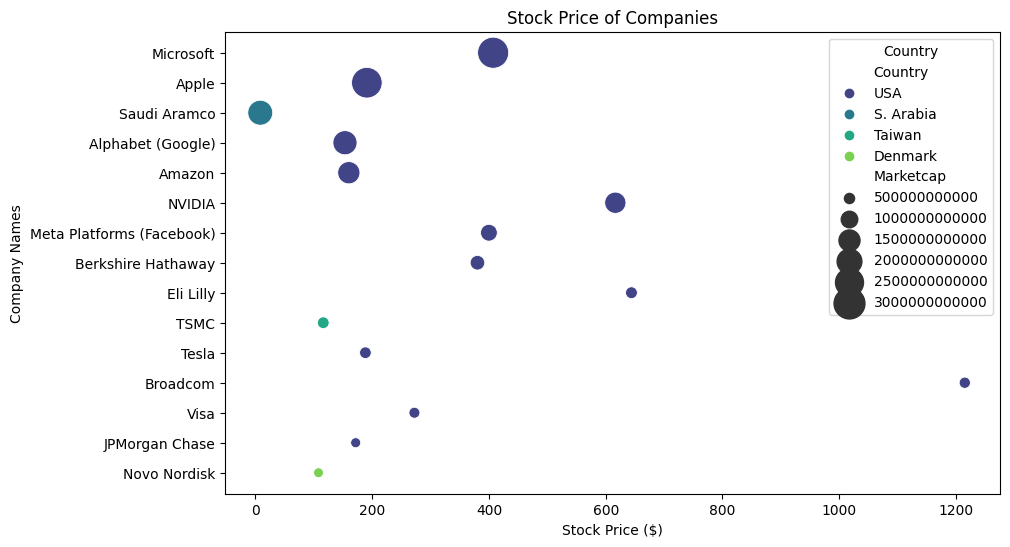

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(y='Company Names', x='Stock Price', data=top_cmp, hue='Country', size='Marketcap', sizes=(50, 500), palette='viridis', ax=ax)
ax.set_title('Stock Price of Companies')
ax.set_ylabel('Company Names')
ax.set_xlabel('Stock Price ($)')
ax.legend(title='Country')
plt.show()

**TOP 1000 COMPANIES**

In [7]:
topk=df.head(1000)

**Distribution of Marketcap by Country with Interchanged Axes**

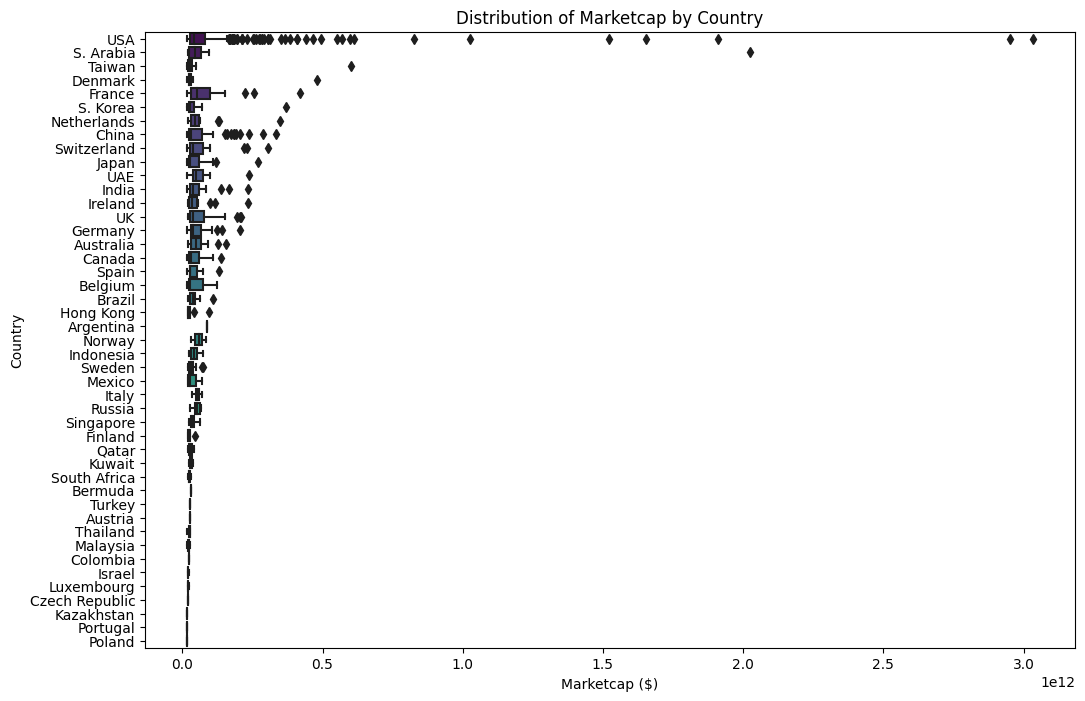

In [8]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='Marketcap', y='Country', data=topk, palette='viridis')
plt.title('Distribution of Marketcap by Country')
plt.xlabel('Marketcap ($)')
plt.ylabel('Country')
plt.show()


**Marketcap Distribution with Interchanged Axes (TOP 15 Companies)**

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


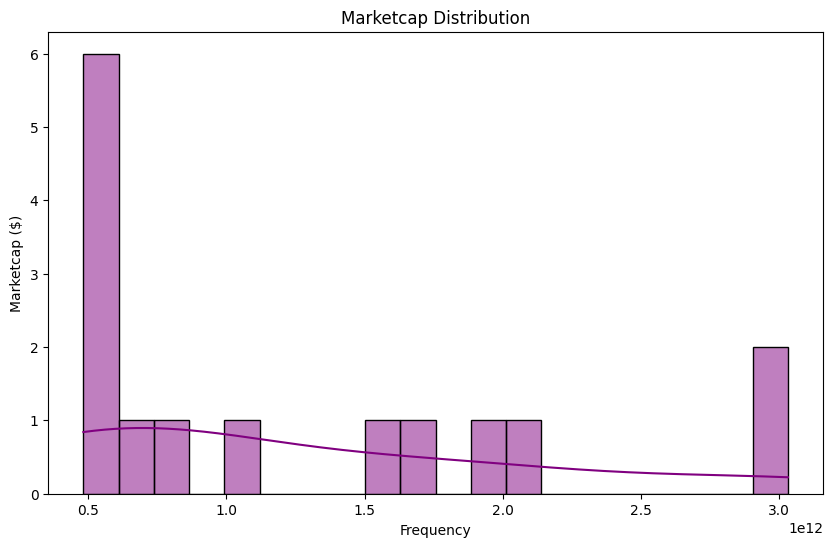

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(top_cmp['Marketcap'], bins=20, kde=True, color='purple', orientation='horizontal')
plt.title('Marketcap Distribution')
plt.xlabel('Frequency')
plt.ylabel('Marketcap ($)')
plt.show()


# Linear Regression:

**Importing the Libraries**

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

**Scatter plot with regression line**

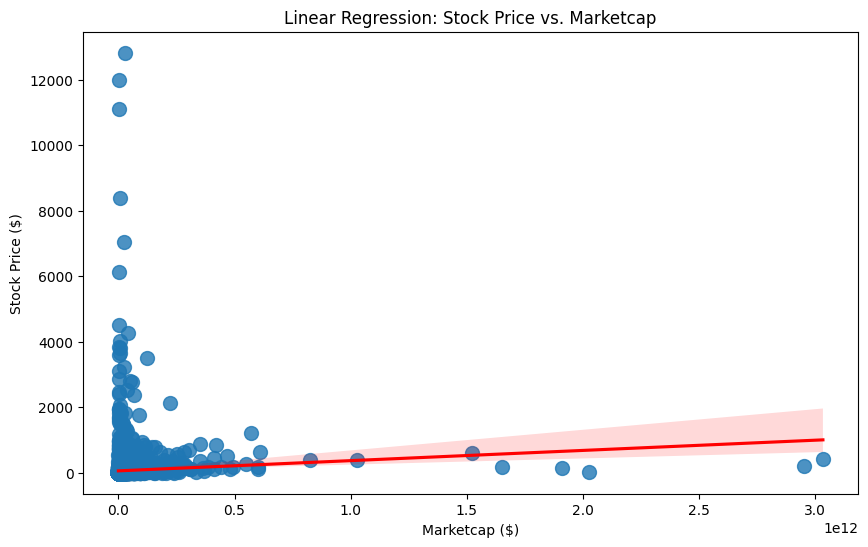

In [11]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Marketcap', y='Stock Price', data=df, scatter_kws={'s': 100}, line_kws={'color': 'red'})
plt.title('Linear Regression: Stock Price vs. Marketcap')
plt.xlabel('Marketcap ($)')
plt.ylabel('Stock Price ($)')
plt.show()